Original equation used to generate the data
y = 0.0629x + 2.5317

Custom Least Squares Results
Slope = -0.1060
Intercept = 2.6495

Numpy Least Squares Results
Slope = -0.1060
Intercept = 2.6495

First 10 Residuals
x = 0.00, residual = -0.4586
x = 0.01, residual = 0.6358
x = 0.02, residual = 0.2306
x = 0.03, residual = -0.1082
x = 0.04, residual = 0.4593
x = 0.05, residual = 0.6839
x = 0.06, residual = 0.2393
x = 0.07, residual = 0.7467
x = 0.08, residual = -0.4344
x = 0.09, residual = 0.0761

Largest Residual
0.9966 at x = 0.76

Smallest Residual
-1.0255 at x = 0.24


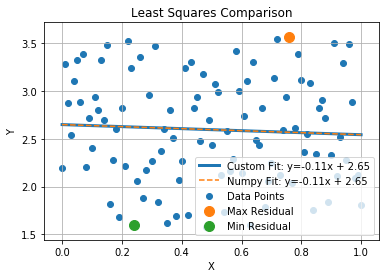

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#Used ChatGpt for plotting, organization, and function

# Custom Least Squares implementation using the formula for slope and intercept
def my_least_squares(x, y):

    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x**2)
    sum_xy = np.sum(x * y)

    # compute slope
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

    # compute intercept
    b = (sum_y - m * sum_x) / n

    return m, b


# Numpy least squares method for comparison
def numpy_ls(x, y):

    n = len(x)

    # build matrix for Ax = b form
    A = np.vstack([x, np.ones(n)]).T

    # solve using numpy
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]

    return m, b


# Calculate residuals and find largest/smallest errors
def residual_check(x, y, m, b):

    y_pred = m * x + b

    # residual = actual - predicted
    residuals = y - y_pred

    # index of largest and smallest residual
    max_i = np.argmax(residuals)
    min_i = np.argmin(residuals)

    return residuals, max_i, min_i, y_pred


# create x values from 0 to 1 in steps of .01
x_vals = np.arange(0, 1.01, 0.01)

# sort x values as required
x_vals = np.sort(x_vals)

n = len(x_vals)


# choose a random linear function
true_m = np.random.rand() * 10
true_b = np.random.rand() * 5

# random error between -1 and 1
noise = np.random.uniform(-1, 1, n)

# generate y data
y_vals = true_m * x_vals + true_b + noise


print("Original equation used to generate the data")
print(f"y = {true_m:.4f}x + {true_b:.4f}\n")


# run custom least squares
m_custom, b_custom = my_least_squares(x_vals, y_vals)

print("Custom Least Squares Results")
print(f"Slope = {m_custom:.4f}")
print(f"Intercept = {b_custom:.4f}\n")


# run numpy least squares
m_np, b_np = numpy_ls(x_vals, y_vals)

print("Numpy Least Squares Results")
print(f"Slope = {m_np:.4f}")
print(f"Intercept = {b_np:.4f}\n")


# compute residuals
residuals, max_index, min_index, y_fit = residual_check(x_vals, y_vals, m_custom, b_custom)


# print first 10 residuals
print("First 10 Residuals")
for i in range(10):
    print(f"x = {x_vals[i]:.2f}, residual = {residuals[i]:.4f}")


# print largest and smallest residual
print("\nLargest Residual")
print(f"{residuals[max_index]:.4f} at x = {x_vals[max_index]:.2f}")

print("\nSmallest Residual")
print(f"{residuals[min_index]:.4f} at x = {x_vals[min_index]:.2f}")


# plot data and fitted lines
plt.figure()

# scatter plot of original data
plt.scatter(x_vals, y_vals, label="Data Points")

# custom least squares line
plt.plot(
    x_vals,
    y_fit,
    linewidth=3,
    label=f"Custom Fit: y={m_custom:.2f}x + {b_custom:.2f}"
)

# numpy least squares line
plt.plot(
    x_vals,
    m_np * x_vals + b_np,
    linestyle="--",
    label=f"Numpy Fit: y={m_np:.2f}x + {b_np:.2f}"
)

# highlight largest and smallest residual points
plt.scatter(x_vals[max_index], y_vals[max_index], s=100, label="Max Residual")
plt.scatter(x_vals[min_index], y_vals[min_index], s=100, label="Min Residual")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Comparison")

plt.legend()
plt.grid(True)

plt.show()